Bloque 1 - Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Bloque 2 - Imporatmos la libreria tensorflow

In [2]:
import tensorflow as tf

BLoque 3 - Descarga de datos

In [3]:
import kagglehub # Importa la librería kagglehub para interactuar con Kaggle y descargar datasets.

path = kagglehub.dataset_download("muhammedjunayed/wavelet-transformed-eeg-data-for-alcohol-detection")

print("Path to dataset files:", path) # Imprime la ruta donde se han descargado los archivos del dataset.

100%|██████████| 21.3M/21.3M [00:02<00:00, 10.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammedjunayed/wavelet-transformed-eeg-data-for-alcohol-detection/versions/1


Bloque 4 - Exploracion de archivos

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


path = Path(path)
img_as_jpg = list(path.rglob(r"*/*.jpg"))

# Counts the number of each categories in the dataset
file_count = list(map(lambda x: os.path.split(os.path.split(x)[0])[1],img_as_jpg))
Alc = file_count.count('Alc')
Con = file_count.count('Con')

In [5]:
Alc

468

In [6]:
Con

456

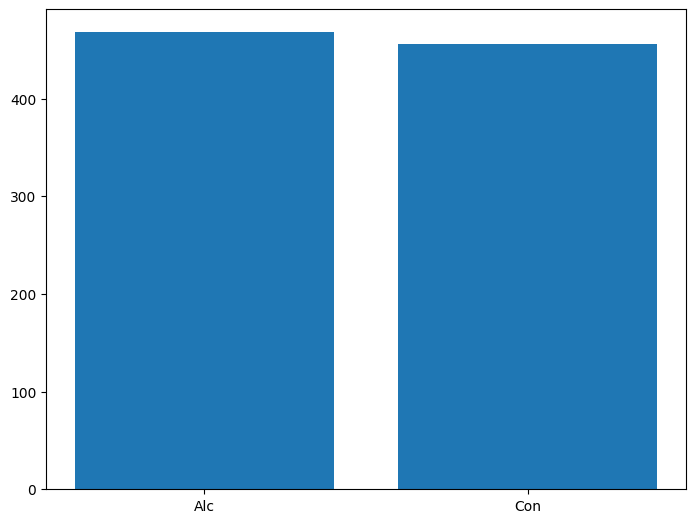

In [7]:
#VISUALIZACION DE DATA POR CLASES ALCOHOL O CONTROL
fig = plt.figure()
ax = fig.add_axes([1,1,1,1])
labels = ['Alc','Con']
count_train = [Alc, Con] # count_train should contain the count of each label
ax.bar(labels, count_train)
plt.show()

BLOQUE 5 - IMPLEMENTACION DEL MODELO PIT

In [8]:
#MODELO PiT (Pooling-based Vision Transformer)
#BLOQUE 01
import tensorflow as tf
from tensorflow.keras import layers, models

# Clase utilitaria para acceder a claves de diccionario como atributos (obj.clave en vez de obj['clave'])
class AttrDict(dict):
    __setattr__ = dict.__setitem__
    __getattr__ = dict.__getitem__


# Función de visualización: Muestra una cuadrícula de imágenes y sus predicciones
# Verifica visualmente si el preprocesamiento (Wavelet) generó imágenes coherentes
def plot_grid_ds(ds, model=None, size=(3, 3), figsize=(10, 10)):
    from copy import copy
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import ImageGrid

    n = size[0] * size[1]
    ds_ = copy(ds)

    fig = plt.figure(figsize=figsize)
    grid = ImageGrid(
        fig,
        111,
        nrows_ncols=size,
        axes_pad=0.3,
    )
# Toma un lote del dataset, hace predicciones si hay modelo, y grafica
    for X_batch, y_batch in ds_.unbatch().shuffle(n).batch(n).take(1):
      # Proporciona un modelo, calcula la clase predicha (argmax de los logits)
        y_hat_batch = model.predict(X_batch).argmax(axis=-1) if model else y_batch
        for X, y, y_hat, ax in zip(X_batch, y_batch, y_hat_batch, grid):
            title = (
                f"{ds.class_names[y]} (true) - {ds.class_names[y_hat]} (pred)"
                if model
                else f"{ds.class_names[y]}"
            )
            ax.set_title(title)
            ax.axes.xaxis.set_visible(False)
            ax.axes.yaxis.set_visible(False)
            # Normaliza la imagen a  para mostrarla correctamente
            ax.imshow(X / 255, cmap="gray")
    return grid

# Métrica personalizada: Precisión Categórica Dispersa Balanceada
# Esencial en datasets (ej. Alcohólico) puede ser menos frecuente
# Pondera los aciertos inversamente a la frecuencia de la clase real
class BalancedSparseCategoricalAccuracy(tf.keras.metrics.SparseCategoricalAccuracy):
    def __init__(self, name="balanced_sparse_categorical_accuracy", dtype=None):
        super().__init__(name, dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_flat = y_true
        if y_true.shape.ndims == y_pred.shape.ndims:
            y_flat = tf.squeeze(y_flat, axis=[-1])
        y_true_int = tf.cast(y_flat, tf.int32)

        # Calculo pesos para equilibrar la importancia de cada clase
        cls_counts = tf.math.bincount(y_true_int)
        cls_counts = tf.math.reciprocal_no_nan(tf.cast(cls_counts, self.dtype))
        weight = tf.gather(cls_counts, y_true_int)
        # Llama a la métrica original pero aplicando los pesos calculados
        return super().update_state(y_true, y_pred, sample_weight=weight)

# --- IMPLEMENTACIÓN DEL MODELO PiT (Pooling-based Vision Transformer) ---

def TransformerBlock(x, heads, key_dim, units, dropout):
    # Layer Normalization 1
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    # MultiHead Attention
    attention_output = layers.MultiHeadAttention(
        num_heads=heads, key_dim=key_dim, dropout=dropout
    )(x1, x1)
    # Skip connection 1
    x2 = layers.Add()([x, attention_output])

    # Layer Normalization 2
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    # MLP
    x3 = layers.Dense(units, activation=tf.nn.gelu)(x3)
    x3 = layers.Dropout(dropout)(x3)
    x3 = layers.Dense(x.shape[-1])(x3) # Project back to input dim
    x3 = layers.Dropout(dropout)(x3)
    # Skip connection 2
    x = layers.Add()([x2, x3])
    return x


class PoolingLayer(layers.Layer):
    def __init__(self, output_dim):
        super(PoolingLayer, self).__init__()
        self.pool = layers.DepthwiseConv2D(kernel_size=3, strides=2, padding='same')
        self.conv = layers.Conv2D(output_dim, kernel_size=1)

    def call(self, inputs):
        # inputs: [B, N, C] -> Necesitamos redimensionar a [B, H, W, C]
        shape = tf.shape(inputs)
        B, N, C = shape[0], shape[1], shape[2]
        H = tf.cast(tf.sqrt(tf.cast(N, tf.float32)), tf.int32)

        x = tf.reshape(inputs, (B, H, H, C))
        x = self.pool(x)
        x = self.conv(x)

        # Aplanar de nuevo: [B, H', W', C'] -> [B, N', C']
        return tf.reshape(x, (B, -1, tf.shape(x)[-1]))


class PiTClassifier(tf.keras.Model):
    def __init__(self, input_shape, n_classes):
        super(PiTClassifier, self).__init__()
        self.input_tensor_shape = input_shape
        self.n_classes = n_classes
        self._construct_model()

    def call(self, x):
        return self._model(x)

    def _construct_model(self):
        # Configuration
        patch_size = 16
        base_dims = [32, 64, 128]
        heads = [2, 4, 8]
        transformers = [2, 2, 2]
        dropout = 0.1
        mlp_ratio = 4

        inputs = layers.Input(shape=self.input_tensor_shape)

        # --- Stage 1 ---
        # Patch Embedding (Spatial reduction)
        x = layers.Conv2D(filters=base_dims[0], kernel_size=patch_size, strides=patch_size, padding='valid')(inputs)

        # Reshape to sequence
        h1, w1 = x.shape[1], x.shape[2]
        seq_len1 = h1 * w1
        x = layers.Reshape((seq_len1, base_dims[0]))(x)

        # Positional Embeddings
        pos_emb1 = layers.Embedding(input_dim=seq_len1, output_dim=base_dims[0])(tf.range(seq_len1))
        x = x + pos_emb1

        # Transformers Stage 1
        for _ in range(transformers[0]):
            x = TransformerBlock(x, heads[0], base_dims[0] // heads[0], base_dims[0] * mlp_ratio, dropout)

        # --- Pooling 1 ---
        # Reshape back to spatial
        x = layers.Reshape((h1, w1, base_dims[0]))(x)
        # Conv Pooling
        x = layers.Conv2D(base_dims[1], kernel_size=3, strides=2, padding='same')(x)

        # --- Stage 2 ---
        h2, w2 = x.shape[1], x.shape[2]
        seq_len2 = h2 * w2
        x = layers.Reshape((seq_len2, base_dims[1]))(x)

        pos_emb2 = layers.Embedding(input_dim=seq_len2, output_dim=base_dims[1])(tf.range(seq_len2))
        x = x + pos_emb2

        # Transformers Stage 2
        for _ in range(transformers[1]):
            x = TransformerBlock(x, heads[1], base_dims[1] // heads[1], base_dims[1] * mlp_ratio, dropout)

        # --- Pooling 2 ---
        x = layers.Reshape((h2, w2, base_dims[1]))(x)
        x = layers.Conv2D(base_dims[2], kernel_size=3, strides=2, padding='same')(x)

        # --- Stage 3 ---
        h3, w3 = x.shape[1], x.shape[2]
        seq_len3 = h3 * w3
        x = layers.Reshape((seq_len3, base_dims[2]))(x)

        pos_emb3 = layers.Embedding(input_dim=seq_len3, output_dim=base_dims[2])(tf.range(seq_len3))
        x = x + pos_emb3

        # Transformers Stage 3
        for _ in range(transformers[2]):
            x = TransformerBlock(x, heads[2], base_dims[2] // heads[2], base_dims[2] * mlp_ratio, dropout)

        # --- Head ---
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(self.n_classes)(x)

        self._model = models.Model(inputs=inputs, outputs=outputs, name="PiT_Internal")

In [22]:
#08
train = pd.concat([pd.Series(img_as_jpg,name="image").apply(str),pd.Series(file_count, name="type")],axis=1)
train = train.sample(frac=1).reset_index(drop=True)
print(np.shape(train))

(924, 2)


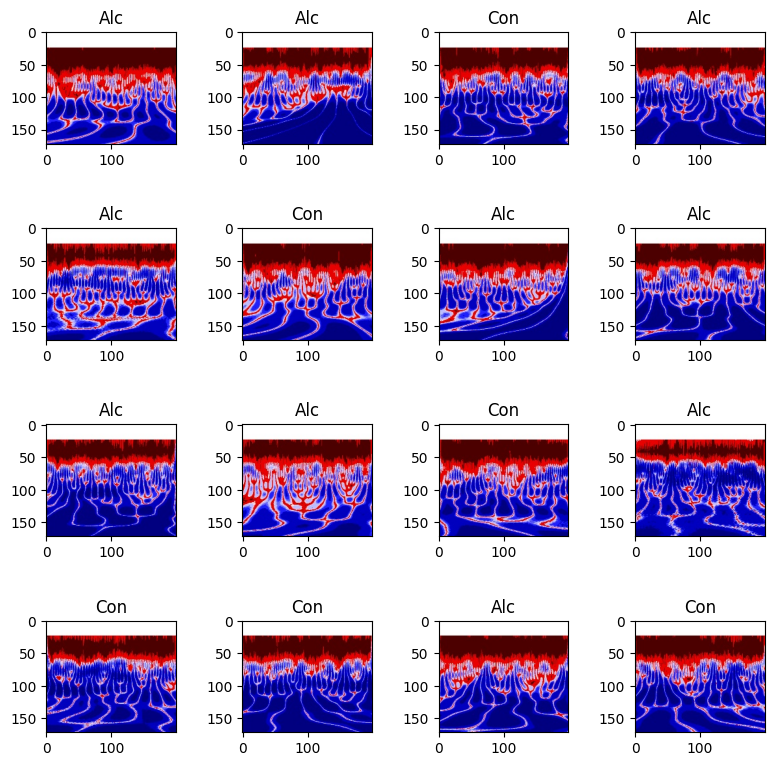

In [29]:
#09
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.tight_layout()
counter = 0
for ax in axes.reshape(-1):
    ax.imshow(plt.imread(train["image"][counter]))
    ax.set_title(train["type"][counter])
    plt.rcParams["axes.grid"] = False
    counter = counter+1

In [30]:
hparams = AttrDict(
    image_size=(224, 224, 3),  # Adjusted to be divisible by patch size
    n_classes=2,
    batch_size=32,
)

ds = tf.keras.preprocessing.image_dataset_from_directory("/content/drive/MyDrive/Papper_Titulo /EEG", image_size=hparams.image_size[:-1], batch_size=hparams.batch_size)
train_split = round(0.8 * ds.cardinality().numpy())
train_ds = ds.take(train_split); train_ds.class_names = ds.class_names
validation_ds = ds.skip(train_split); validation_ds.class_names = ds.class_names

Found 924 files belonging to 2 classes.


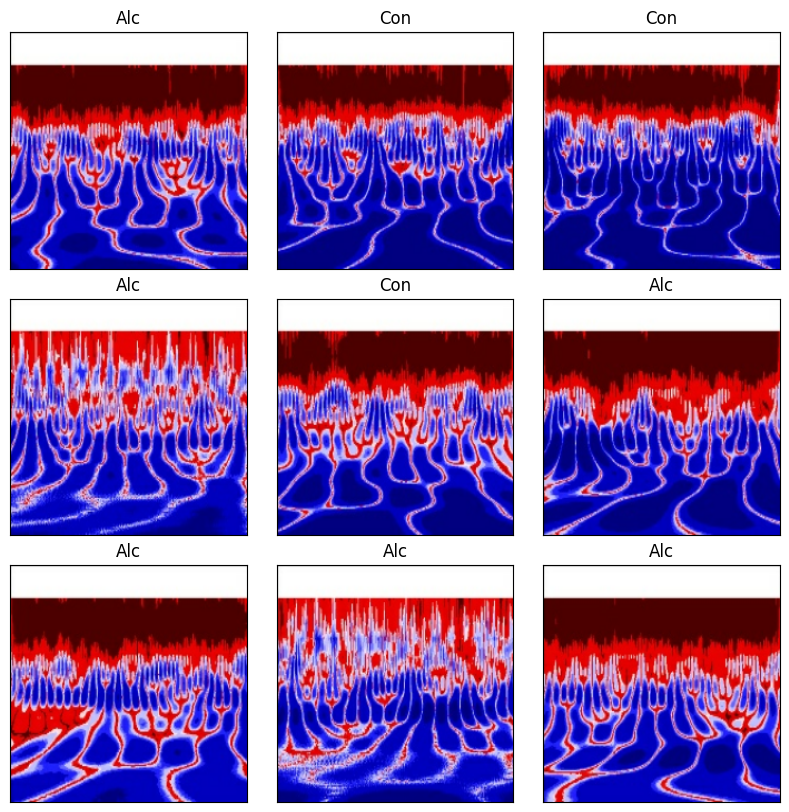

In [31]:
_ = plot_grid_ds(train_ds)


BLOQUE 5: RESULTADOS DEL MODELO PIT

---



Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.5488 - balanced_sparse_categorical_accuracy: 0.5027 - loss: 44.3599 - val_accuracy: 0.5426 - val_balanced_sparse_categorical_accuracy: 0.5320 - val_loss: 4.1758
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.5707 - balanced_sparse_categorical_accuracy: 0.5729 - loss: 3.1479 - val_accuracy: 0.6277 - val_balanced_sparse_categorical_accuracy: 0.6397 - val_loss: 1.3584
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.6018 - balanced_sparse_categorical_accuracy: 0.5936 - loss: 1.3768 - val_accuracy: 0.5904 - val_balanced_sparse_categorical_accuracy: 0.5638 - val_loss: 1.2924
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.6257 - balanced_sparse_categorical_accuracy: 0.6137 - loss: 0.8914 - val_accuracy: 0.6862 - val_balanced_sparse_categorical_accuracy: 0.6751 - val_loss: 0.6766
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.7009 - balanced_sparse_categ

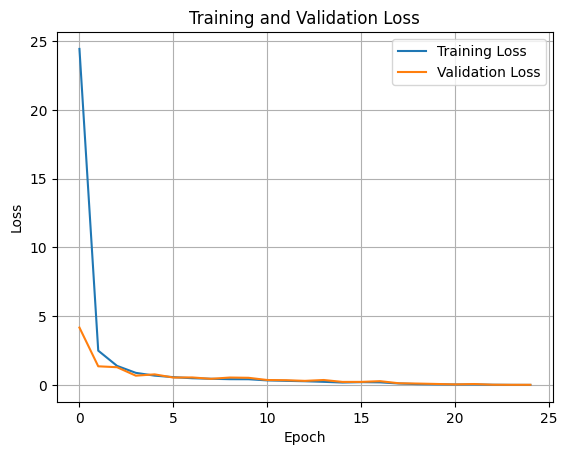

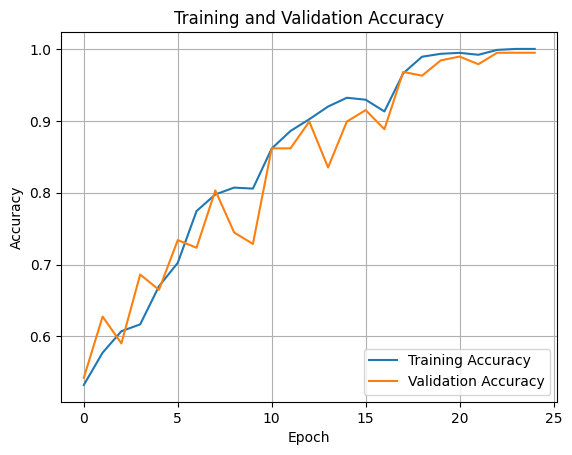

Final Training Accuracy: 100.00%
Final Validation Accuracy: 99.47%
Total time taken: 93.84 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step


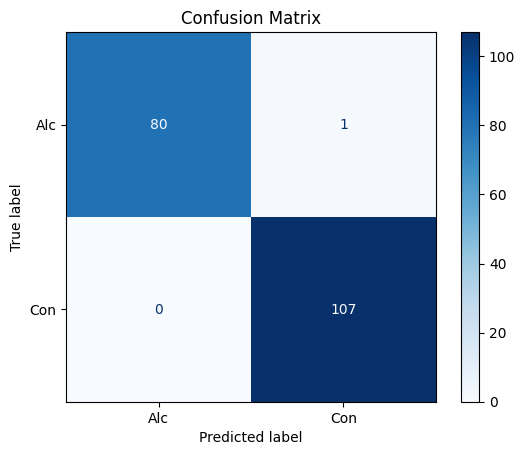


Class-wise Precision: [1.         0.99074074]

Class-wise Recall: [0.98765432 1.        ]

Class-wise F1-score: [0.99378882 0.99534884]

Overall Accuracy: 99.47%

Macro Precision: 0.9953703703703703

Macro Recall: 0.9938271604938271

Macro F1-score: 0.9945688285425394


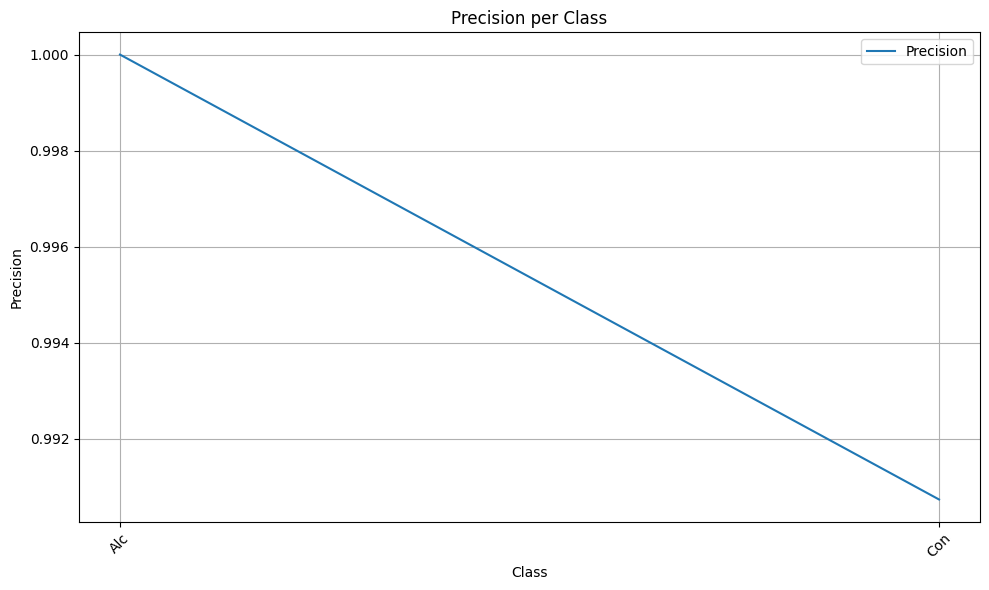

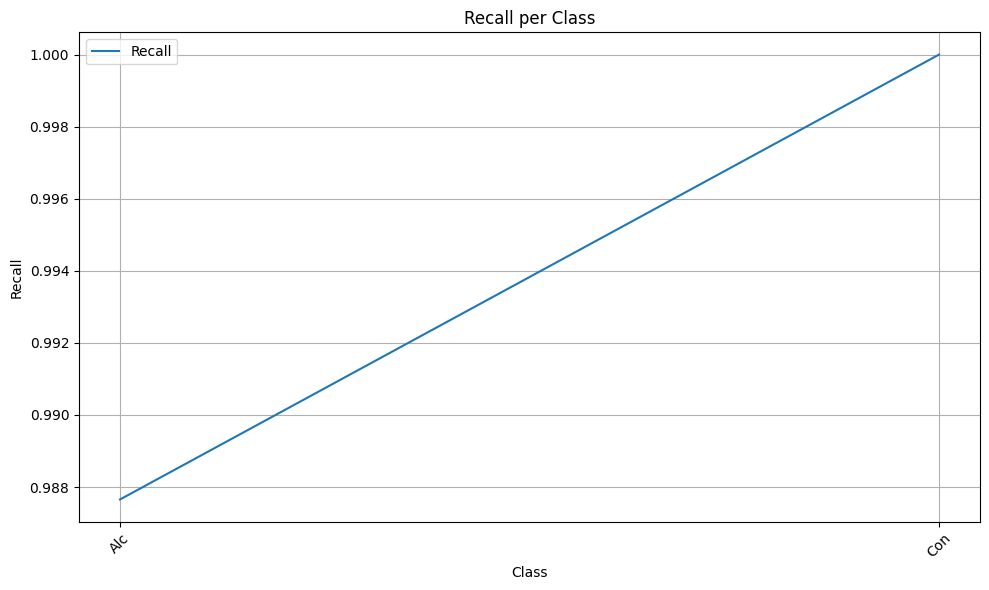

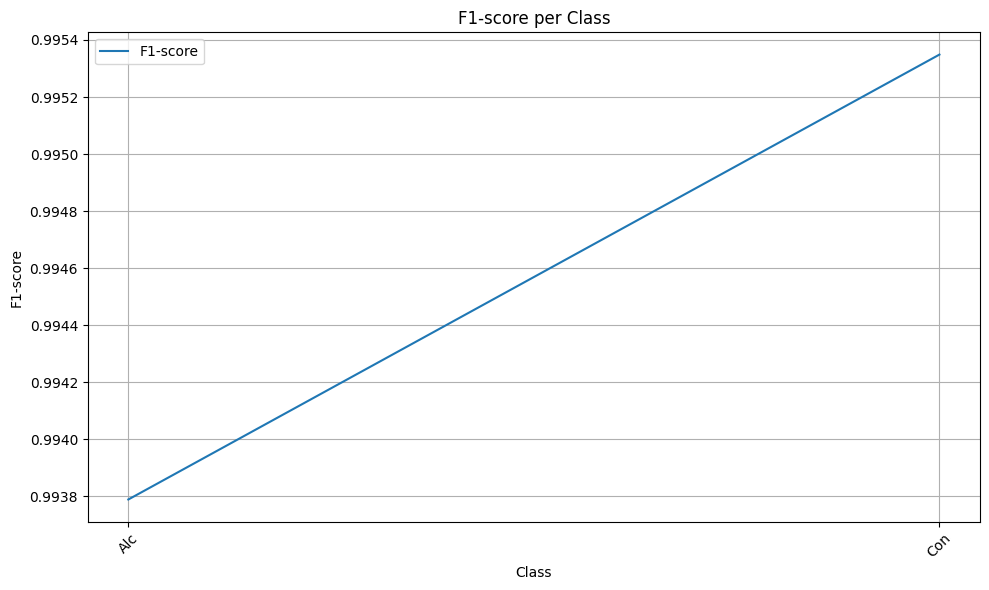

In [32]:
import time
import tensorflow as tf
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- FIX: Re-instantiate model to ensure the updated class definition is used ---
# Check if strategy exists, otherwise create it
if 'strategy' not in globals():
    strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    # Convert hparams to a regular dictionary for compatibility if needed, or access directly
    # Assuming hparams is available from previous cells
    input_shape = hparams['image_size']
    n_classes = hparams['n_classes']

    # Re-build the model with the CORRECTED PiTClassifier class
    model = PiTClassifier(input_shape, n_classes)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy", BalancedSparseCategoricalAccuracy()]
    )
# --------------------------------------------------------------------------------

start = time.time()

# Configure a callback to record loss and accuracy during training
class TrainingHistory(tf.keras.callbacks.Callback):
  def __init__(self):
    self.losses = []
    self.val_losses = []
    self.accuracies = []
    self.val_accuracies = []

  def on_epoch_end(self, epoch, logs=None):
    self.losses.append(logs.get('loss'))
    self.val_losses.append(logs.get('val_loss'))
    self.accuracies.append(logs.get('accuracy'))
    self.val_accuracies.append(logs.get('val_accuracy'))

# Train the model with the configured callback
history_pit = TrainingHistory()
model.fit(train_ds, epochs=25, validation_data=validation_ds, callbacks=[history_pit])

# Plot the training and validation loss curves
plt.plot(history_pit.losses, label='Training Loss')
plt.plot(history_pit.val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Plot the training and validation accuracy curves
plt.plot(history_pit.accuracies, label='Training Accuracy')
plt.plot(history_pit.val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print final overall accuracy
final_accuracy = history_pit.accuracies[-1]
final_val_accuracy = history_pit.val_accuracies[-1]
print(f"Final Training Accuracy: {final_accuracy * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_accuracy * 100:.2f}%")

end = time.time()
print(f"Total time taken: {end - start:.2f} seconds")

## Confusion Matrix and Metrics Calculation

# Assuming you have already trained the model and have the validation dataset (validation_ds)

# Get true labels and predictions
X_val, y_true = [], []
for images, labels in validation_ds:
    X_val.extend(images.numpy())
    y_true.extend(labels.numpy())
X_val = np.array(X_val)
y_true = np.array(y_true)

# Make predictions
y_pred = model.predict(X_val).argmax(axis=1)

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title('Confusion Matrix')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(y_true, y_pred, class_names=validation_ds.class_names)

# Calculate and print classification metrics
class_wise_precision = precision_score(y_true, y_pred, average=None)
class_wise_recall = recall_score(y_true, y_pred, average=None)
class_wise_f1 = f1_score(y_true, y_pred, average=None)

print("\nClass-wise Precision:", class_wise_precision)
print("\nClass-wise Recall:", class_wise_recall)
print("\nClass-wise F1-score:", class_wise_f1)

# Overall Scores
accuracy = np.mean(y_true == y_pred)
macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall = recall_score(y_true, y_pred, average='macro')
macro_f1 = f1_score(y_true, y_pred, average='macro')

# Print overall accuracy in percentage
print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")
print("\nMacro Precision:", macro_precision)
print("\nMacro Recall:", macro_recall)
print("\nMacro F1-score:", macro_f1)

# Plot precision, recall, and F1-score for each class
plt.figure(figsize=(10, 6))
plt.plot(class_wise_precision, label='Precision')
plt.xticks(range(len(class_wise_precision)), validation_ds.class_names, rotation=45)
plt.xlabel('Class')
plt.ylabel('Precision')
plt.title('Precision per Class')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(class_wise_recall, label='Recall')
plt.xticks(range(len(class_wise_recall)), validation_ds.class_names, rotation=45)
plt.xlabel('Class')
plt.ylabel('Recall')
plt.title('Recall per Class')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(class_wise_f1, label='F1-score')
plt.xticks(range(len(class_wise_f1)), validation_ds.class_names, rotation=45)
plt.xlabel('Class')
plt.ylabel('F1-score')
plt.title('F1-score per Class')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


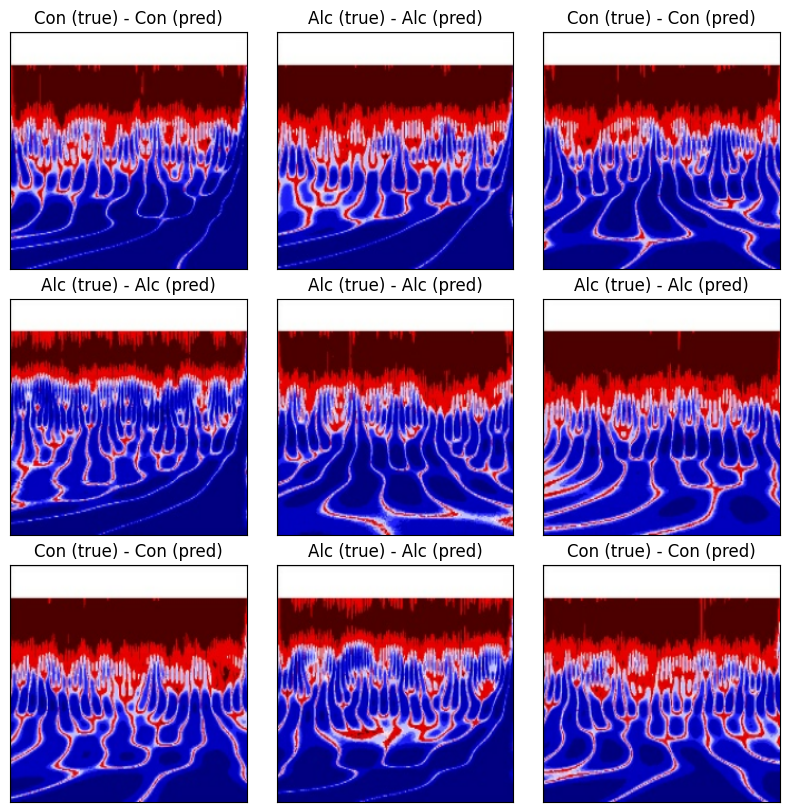

In [ ]:
_ = plot_grid_ds(validation_ds,  model=model)

In [33]:
print("\nMacro F1-score:", macro_f1)



Macro F1-score: 0.9945688285425394


In [34]:
import pandas as pd

# === Datos del modelo (ajusta el nombre si quieres) ===
MODEL_NAME = "PiT"
EPOCHS = 25
BATCH_SIZE = hparams.batch_size

# Obtener LR y optimizador desde el propio modelo
learning_rate = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
optimizer_name = type(model.optimizer).__name__

# Crear DataFrame con una fila de resultados
df_resultados = pd.DataFrame([{
    "Model": MODEL_NAME,
    "Accuracy": round(accuracy, 4),
    "Precision": round(macro_precision, 4),
    "Recall": round(macro_recall, 4),
    "F1-Score": round(macro_f1, 4),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,

}])

# Mostrar tabla bonita en el notebook
df_resultados

,Model,Accuracy,Precision,Recall,F1-Score,batch_size,epochs
0,PiT,0.9947,0.9954,0.9938,0.9946,32,25


In [35]:
# Parche para corregir el conflicto de 'AttrDict' con la inspección de variables de Colab
# Esto evita el KeyError: 'shape' al cambiarlo por el AttributeError esperado
try:
    if 'AttrDict' in globals():
        def getattr_patch(self, key):
            try:
                return self[key]
            except KeyError:
                raise AttributeError(f"'AttrDict' object has no attribute '{key}'")
        AttrDict.__getattr__ = getattr_patch
except Exception:
    pass

# Definir la ruta donde se guardará el modelo
# Se utiliza la extensión .keras que es el formato recomendado actualmente
save_path = '/content/drive/MyDrive/Papper_Titulo /02_PiT_EEG_Alcohol_Detection.keras'

# Guardar el modelo
model.save(save_path)

print(f"Modelo guardado exitosamente en: {save_path}")

Modelo guardado exitosamente en: /content/drive/MyDrive/Papper_Titulo /02_PiT_EEG_Alcohol_Detection.keras


In [36]:
# Tabla por clase
df_por_clase = pd.DataFrame({
    "Class": validation_ds.class_names,
    "Precision": class_wise_precision,
    "Recall": class_wise_recall,
    "F1-Score": class_wise_f1,
})

df_por_clase

,Class,Precision,Recall,F1-Score
0,Alc,1.000000,0.987654,0.993789
1,Con,0.990741,1.000000,0.995349
